In [1]:
import os
import sys
import json
import time
import platform
import subprocess
from pathlib import Path

ROOT = Path("/kaggle/working/llm-lab")
for d in ["src", "results", "plots", "logs"]:
    (ROOT / d).mkdir(parents=True, exist_ok=True)
os.chdir(ROOT)

# Keep heavy caches out of /kaggle/working so Save Version stays small
os.environ["HF_HOME"] = "/tmp/hf_cache"
os.environ["UV_LINK_MODE"] = "copy"
VENV = Path("/tmp/vllm_env")

# Session clock survives kernel restarts (but not a brand new session)
_clock = Path("/tmp/session_start.txt")
if not _clock.exists():
    _clock.write_text(str(time.time()))
SESSION_START = float(_clock.read_text())
MAX_SESSION_H = 10.5  # hard stop well before Kaggle's 12h limit


def hours_used():
    return (time.time() - SESSION_START) / 3600


def check_budget(next_step_h):
    # Refuse to start a new step if it might not finish inside the session
    if hours_used() + next_step_h > MAX_SESSION_H:
        raise RuntimeError(
            f"Time budget: {hours_used():.1f}h used, next step needs ~{next_step_h}h. "
            "Download results and stop."
        )


gpu = subprocess.run(
    "nvidia-smi --query-gpu=name,memory.total --format=csv,noheader",
    shell=True, capture_output=True, text=True,
).stdout
print(gpu or "NO GPU FOUND - set Accelerator to GPU T4 x2 in Settings")

Tesla T4, 15360 MiB
Tesla T4, 15360 MiB



In [2]:
import shutil

# Find every previous llm-lab output folder inside the attached notebook outputs
roots = sorted({p.parent.parent for p in Path("/kaggle/input").rglob("results/env.json")})
print("Found previous outputs:", [str(r) for r in roots])
assert roots, "No previous llm-lab output found. Attach the previous notebook via Add Input."

copied = 0
for root in roots:
    for sub, pattern in [("results", "*.json"), ("logs", "*.log")]:
        for src in sorted((root / sub).glob(pattern)):
            if src.name.startswith("smoke"):
                continue
            name = src.name
            if name == "env.json":
                name = "env_first_run.json"
            elif name.startswith("vllm_"):
                # Old vLLM runs had prefix caching ON with identical prompts: keep them under a new name
                name = name.replace("vllm_", "vllm_prefixcache_", 1)
            dst = ROOT / sub / name
            if not dst.exists():
                shutil.copy(src, dst)
                copied += 1
print("Files copied:", copied)

counts = {b: len(list((ROOT / "results").glob(f"{b}_p*_r*.json")))
          for b in ["vllm_prefixcache", "hf_naive"]}
print(counts)
assert all(v == 9 for v in counts.values()), f"Expected 9 files per backend, got {counts}"

Found previous outputs: ['/kaggle/input/notebooks/eslamelokpy/bench-inference-py/llm-lab']
Files copied: 21
{'vllm_prefixcache': 9, 'hf_naive': 9}


In [3]:
# The hf_batched raw files were lost with the previous draft session.
# These rows are copied verbatim from that run's printed log (full float precision).
# Each tuple: prompt_len, repeat, concurrency, n_requests, ttft_p50_s, ttft_p95_s,
#             latency_p50_s, throughput_tok_s, peak_gpu_mib
HF_BATCHED_ROWS = [
    (128, 0, 1, 8, 0.06324416799998289, 0.08246667100002014, 4.641149810999991, 27.580830161572383, 3317),
    (128, 0, 4, 8, 0.10507372099999657, 0.10567525500005104, 4.6601362270000095, 109.85918820223533, 3333),
    (128, 0, 16, 32, 0.38021434800003817, 0.3813955680000163, 5.469188035000002, 374.38189132720794, 3575),
    (128, 0, 64, 128, 16.98710024799999, 17.057254388999922, 22.13632022950003, 369.85621415662905, 3575),
    (128, 1, 1, 8, 0.06414258300003439, 0.0696328319999111, 4.687762474500005, 27.30171606105419, 3575),
    (128, 1, 4, 8, 0.10839327849998881, 0.1108537370000704, 4.717372773500017, 108.51693405160871, 3575),
    (128, 1, 16, 32, 0.378229205499963, 0.385523267999929, 5.477215908000005, 373.8190042453471, 3575),
    (128, 1, 64, 128, 16.674662320500033, 16.742852763999963, 21.76131061000001, 374.9924576225971, 3575),
    (128, 2, 1, 8, 0.06307729350004365, 0.06571811499998148, 4.6704974719999655, 27.401056733050446, 3575),
    (128, 2, 4, 8, 0.10777087750000192, 0.10870874500005812, 4.659603195999978, 109.86868450622887, 3575),
    (128, 2, 16, 32, 0.3676713100000484, 0.37179693600000974, 5.548641809499998, 369.03025557689085, 3575),
    (128, 2, 64, 128, 16.733232066500022, 16.957411621999995, 21.822914747500022, 373.3792143085312, 3575),
    (512, 0, 1, 8, 0.13099715449999394, 0.13474453499998162, 4.74479163649994, 27.032723459292136, 3575),
    (512, 0, 4, 8, 0.4629157545000453, 0.46665119300018887, 4.946730799999955, 103.4915363593216, 3671),
    (512, 0, 16, 32, 1.7097612464999656, 1.7123018199999933, 10.738142156999857, 190.69050069649393, 4435),
    (512, 0, 64, 128, 34.156327850499906, 34.267946160000065, 43.203910567499975, 189.6014615894342, 4435),
    (512, 1, 1, 8, 0.13120936200004962, 0.13632568100001663, 4.746481239499985, 26.932288628665123, 4435),
    (512, 1, 4, 8, 0.46758657749990107, 0.4705680399999892, 4.945634998499827, 103.51203060392841, 4435),
    (512, 1, 16, 32, 1.7223911694999288, 1.726548024999829, 10.762041576499882, 190.2702384891943, 4435),
    (512, 1, 64, 128, 34.14747884600001, 34.22942772800002, 43.204774922999945, 189.59224732904573, 4435),
    (512, 2, 1, 8, 0.1322221210001544, 0.1378437920000124, 4.745941422999977, 26.917231680208985, 4435),
    (512, 2, 4, 8, 0.4721158905000493, 0.4779914429998371, 4.980930572500029, 102.78552839159171, 4435),
    (512, 2, 16, 32, 1.7191278820000662, 1.7244875710000542, 10.752955107000048, 190.4329906141203, 4435),
    (512, 2, 64, 128, 34.13618510800006, 34.214711611999974, 43.18701674399995, 189.68106688690395, 4435),
    (2048, 0, 1, 8, 0.7877872870001283, 0.8208110959999431, 5.39443391650002, 23.72801365348315, 5203),
    (2048, 0, 4, 8, 2.979425102499931, 3.002379069999961, 11.37378636799997, 45.01336946636199, 6739),
    (2048, 0, 16, 32, 12.804685144500013, 12.898080706999963, 38.85652071000004, 52.70532374888233, 12883),
    (2048, 0, 64, 128, 129.08439257199996, 129.238152141, 155.15909661850003, 52.77857530209908, 12883),
    (2048, 1, 1, 8, 0.7904046085000118, 0.8203068569998777, 5.4226255700000365, 23.618646514416664, 12883),
    (2048, 1, 4, 8, 2.978219759999888, 3.0024366109998937, 11.373782772999903, 45.01309330483946, 12883),
    (2048, 1, 16, 32, 12.709976471000118, 12.865335870999843, 38.752775405999955, 52.846684553711505, 12883),
    (2048, 1, 64, 128, 129.17702379999992, 129.25607306700022, 155.23613912299993, 52.763847639148345, 12883),
    (2048, 2, 1, 8, 0.7890831740000976, 0.8221309719997407, 5.382318973499878, 23.689052164771056, 12883),
    (2048, 2, 4, 8, 2.9787221005001356, 2.999488348000341, 11.373534379499915, 45.01405028101178, 12883),
    (2048, 2, 16, 32, 12.691950491499938, 12.844106462999662, 38.747201155000084, 52.8540723239228, 12883),
    (2048, 2, 64, 128, 129.15307033099998, 129.25323301100025, 155.19916887399995, 52.767759244910586, 12883),
]

keys = ["concurrency", "n_requests", "ttft_p50_s", "ttft_p95_s",
        "latency_p50_s", "throughput_tok_s", "peak_gpu_mib"]
grouped = {}
for plen, rep, *vals in HF_BATCHED_ROWS:
    grouped.setdefault((plen, rep), []).append(dict(zip(keys, vals)))

written = 0
for (plen, rep), rows in sorted(grouped.items()):
    out = ROOT / "results" / f"hf_batched_p{plen}_r{rep}.json"
    if out.exists():  # real raw file from an attached output wins
        continue
    out.write_text(json.dumps({"backend": "hf_batched", "model": "Qwen/Qwen2.5-1.5B-Instruct",
                               "prompt_len": plen, "max_tokens": 128, "rows": rows}, indent=2))
    written += 1

(ROOT / "results" / "hf_batched_SOURCE.txt").write_text(
    "hf_batched result files were reconstructed from the printed log of the original run "
    "(raw files were lost with the draft session). Config: static batching, max_batch=16, "
    "max_wait_ms=20, requests_per_level=2, Tesla T4, transformers 5.0.0, torch 2.10.0+cu128.\n")

n = len(list((ROOT / "results").glob("hf_batched_p*_r*.json")))
print(f"Wrote {written} files, hf_batched total: {n}")
assert n == 9

Wrote 9 files, hf_batched total: 9


In [4]:
%%bash
set -e
export UV_LINK_MODE=copy
pip install -q uv aiohttp fastapi uvicorn

# Skip the heavy install if the venv already has vllm (e.g. cell re-run)
if [ ! -x /tmp/vllm_env/bin/vllm ]; then
    rm -rf /tmp/vllm_env
    uv venv /tmp/vllm_env
    uv pip install --python /tmp/vllm_env/bin/python vllm --torch-backend=auto
fi

/tmp/vllm_env/bin/python -c "import vllm; print('vllm', vllm.__version__)"
python -c "
from huggingface_hub import snapshot_download
snapshot_download('Qwen/Qwen2.5-1.5B-Instruct')
print('model cached')
"

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 20.4/20.4 MB 84.7 MB/s eta 0:00:00
vllm 0.30.0
model cached


Using CPython 3.12.13 interpreter at: /usr/bin/python3
Creating virtual environment at: /tmp/vllm_env
Activate with: source /tmp/vllm_env/bin/activate
Using Python 3.12.13 environment at: /tmp/vllm_env
Resolved 198 packages in 3.59s
 Downloaded torchcodec
 Downloaded torchvision
 Downloaded triton
 Downloaded openai-harmony
 Downloaded llguidance
 Downloaded tokenizers
 Downloaded nccl4py
 Downloaded numba
 Downloaded nvidia-cutlass-dsl-libs-base
 Downloaded torch
 Downloaded apache-tvm-ffi
 Downloaded outlines-core
 Downloaded nvidia-cuda-cccl
 Downloaded hf-xet
 Downloaded uvloop
 Downloaded cryptography
 Downloaded nvidia-cuda-runtime
 Downloaded nvidia-cuda-nvdisasm
 Downloaded xgrammar
 Downloaded anthropic
 Downloaded nvidia-cutlass-dsl-libs-core
 Downloaded networkx
 Downloaded setuptools
 Downloaded instanttensor
 Downloaded sympy
 Downloaded mistral-common
 Downloaded sentencepiece
 Downloaded nvidia-cufile
 Downloaded pygments
 Downloaded fastsafetensors
 Downloaded aiohttp
 

In [5]:
# Reuse the exact client used in the previous runs, so all backends share identical measurement code
client_src = next(r / "src/bench_inference.py" for r in roots if (r / "src/bench_inference.py").exists())
shutil.copy(client_src, ROOT / "src/bench_inference.py")
print("Client copied from", client_src)

Client copied from /kaggle/input/notebooks/eslamelokpy/bench-inference-py/llm-lab/src/bench_inference.py


In [6]:
import signal
import urllib.request

MODEL = "Qwen/Qwen2.5-1.5B-Instruct"
PORT = 8000
PROMPT_LENS = [128, 512, 2048]
CONCURRENCY = [1, 4, 16, 64]
MAX_TOKENS = 128
REPEATS = 3

# Opener that ignores any proxy env vars, so health checks always hit localhost directly
_no_proxy_opener = urllib.request.build_opener(urllib.request.ProxyHandler({}))


def gpu_used_mib():
    out = subprocess.run(
        "nvidia-smi --id=0 --query-gpu=memory.used --format=csv,noheader,nounits",
        shell=True, capture_output=True, text=True).stdout
    return int(out.strip())


def start_server(cmd, log_path, timeout=900):
    # Pin to GPU 0 and start in its own process group so we can kill all children later
    env = {**os.environ, "CUDA_VISIBLE_DEVICES": "0"}
    log = open(log_path, "w")
    proc = subprocess.Popen(cmd, env=env, stdout=log, stderr=subprocess.STDOUT,
                            start_new_session=True)
    start = time.time()
    while time.time() - start < timeout:
        if proc.poll() is not None:
            print(Path(log_path).read_text()[-3000:])
            raise RuntimeError(f"Server exited early, see {log_path}")
        try:
            _no_proxy_opener.open(f"http://localhost:{PORT}/health", timeout=2)
            print(f"Server ready after {time.time() - start:.0f}s")
            return proc
        except Exception:
            time.sleep(5)
    os.killpg(os.getpgid(proc.pid), signal.SIGKILL)
    raise TimeoutError("Server did not become healthy in time")


def stop_server(proc):
    # Kill the whole process group and wait until the GPU memory is actually released
    try:
        os.killpg(os.getpgid(proc.pid), signal.SIGTERM)
        proc.wait(timeout=60)
    except Exception:
        try:
            os.killpg(os.getpgid(proc.pid), signal.SIGKILL)
        except Exception:
            pass
    for _ in range(30):
        if gpu_used_mib() < 500:
            break
        time.sleep(2)
    print(f"Server stopped, GPU memory used: {gpu_used_mib()} MiB")


def run_backend(name, server_cmd, requests_per_level,
                prompt_lens=None, concurrency=None, repeats=None):
    prompt_lens = prompt_lens or PROMPT_LENS
    concurrency = concurrency or CONCURRENCY
    repeats = repeats or REPEATS
    jobs = [(p, r, ROOT / "results" / f"{name}_p{p}_r{r}.json")
            for p in prompt_lens for r in range(repeats)]
    todo = [j for j in jobs if not j[2].exists()]
    if not todo:
        print(f"{name}: all results already exist, nothing to do")
        return
    check_budget(1.0)
    proc = start_server(server_cmd, ROOT / "logs" / f"{name}_server.log")
    try:
        for plen, rep, out in todo:
            check_budget(0.25)
            print(f"--- {name} prompt_len={plen} repeat={rep} "
                  f"(session {hours_used():.2f}h) ---", flush=True)
            cmd = [sys.executable, str(ROOT / "src/bench_inference.py"),
                   "--model", MODEL, "--backend-name", name,
                   "--base-url", f"http://localhost:{PORT}",
                   "--prompt-len", str(plen), "--max-tokens", str(MAX_TOKENS),
                   "--requests-per-level", str(requests_per_level),
                   "--concurrency", *map(str, concurrency),
                   "--out", str(out)]
            r = subprocess.run(cmd)
            if r.returncode != 0:
                raise RuntimeError(f"Benchmark failed for {out.name}")
    finally:
        stop_server(proc)


def write_env():
    def sh(c):
        lines = subprocess.run(c, shell=True, capture_output=True, text=True).stdout.strip().splitlines()
        return lines[-1] if lines else ""
    import torch
    import transformers
    info = {
        "gpu": sh("nvidia-smi --id=0 --query-gpu=name,driver_version,memory.total --format=csv,noheader"),
        "python": platform.python_version(),
        "torch_client_env": torch.__version__,
        "transformers": transformers.__version__,
        "vllm": sh(f"{VENV}/bin/python -c 'import vllm; print(vllm.__version__)'"),
        "torch_vllm_env": sh(f"{VENV}/bin/python -c 'import torch; print(torch.__version__)'"),
        "model": MODEL, "dtype": "float16", "vllm_prefix_caching": False,
    }
    (ROOT / "results" / "env.json").write_text(json.dumps(info, indent=2))
    print(info)


write_env()

# Prefix caching is OFF: every request uses the same prompt, so caching would hide the real prefill cost
VLLM_CMD = [str(VENV / "bin/vllm"), "serve", MODEL, "--dtype", "float16",
            "--max-model-len", "4096", "--gpu-memory-utilization", "0.85",
            "--no-enable-prefix-caching", "--port", str(PORT)]

{'gpu': 'Tesla T4, 580.178.04, 15360 MiB', 'python': '3.12.13', 'torch_client_env': '2.10.0+cu128', 'transformers': '5.0.0', 'vllm': '0.30.0', 'torch_vllm_env': '2.13.0+cu132', 'model': 'Qwen/Qwen2.5-1.5B-Instruct', 'dtype': 'float16', 'vllm_prefix_caching': False}


In [7]:
assert gpu_used_mib() < 500, f"GPU still in use ({gpu_used_mib()} MiB)"

run_backend("smoke_vllm_nc", VLLM_CMD, requests_per_level=1,
            prompt_lens=[2048], concurrency=[1, 4], repeats=1)
res = json.loads((ROOT / "results/smoke_vllm_nc_p2048_r0.json").read_text())
for row in res["rows"]:
    print(row)

log = (ROOT / "logs/smoke_vllm_nc_server.log").read_text()
print([l[-220:] for l in log.splitlines() if "prefix" in l.lower()][:3])

for f in (ROOT / "results").glob("smoke_*"):
    f.unlink()

Server ready after 150s
--- smoke_vllm_nc prompt_len=2048 repeat=0 (session 0.11h) ---
{'concurrency': 1, 'n_requests': 8, 'ttft_p50_s': 0.8691758209999989, 'ttft_p95_s': 0.8776686219999874, 'latency_p50_s': 3.0381631944999867, 'throughput_tok_s': 42.108381721613, 'peak_gpu_mib': 12361}
{'concurrency': 4, 'n_requests': 8, 'ttft_p50_s': 2.5774381155000015, 'ttft_p95_s': 3.4631374929999765, 'latency_p50_s': 6.115210902000001, 'throughput_tok_s': 83.47113420392974, 'peak_gpu_mib': 12361}
Server stopped, GPU memory used: 0 MiB
{'concurrency': 1, 'n_requests': 8, 'ttft_p50_s': 0.8691758209999989, 'ttft_p95_s': 0.8776686219999874, 'latency_p50_s': 3.0381631944999867, 'throughput_tok_s': 42.108381721613, 'peak_gpu_mib': 12361}
{'concurrency': 4, 'n_requests': 8, 'ttft_p50_s': 2.5774381155000015, 'ttft_p95_s': 3.4631374929999765, 'latency_p50_s': 6.115210902000001, 'throughput_tok_s': 83.47113420392974, 'peak_gpu_mib': 12361}
["tils.py:286] non-default args: {'model_tag': 'Qwen/Qwen2.5-1.5B-In

In [8]:
import traceback

try:
    run_backend("vllm", VLLM_CMD, requests_per_level=4)
except Exception:
    traceback.print_exc()  # keep going so the analysis cell still runs

Server ready after 95s
--- vllm prompt_len=128 repeat=0 (session 0.15h) ---


{'concurrency': 1, 'n_requests': 8, 'ttft_p50_s': 0.039284403999999995, 'ttft_p95_s': 0.04177538499993716, 'latency_p50_s': 2.0413893369999414, 'throughput_tok_s': 62.439538629339694, 'peak_gpu_mib': 12711}
{'concurrency': 4, 'n_requests': 16, 'ttft_p50_s': 0.10461026550001407, 'ttft_p95_s': 0.11520546300016576, 'latency_p50_s': 2.129176639499974, 'throughput_tok_s': 240.31368436224403, 'peak_gpu_mib': 12711}
{'concurrency': 16, 'n_requests': 64, 'ttft_p50_s': 0.3522368420000248, 'ttft_p95_s': 0.3634194810001645, 'latency_p50_s': 2.829769375000069, 'throughput_tok_s': 723.955295261734, 'peak_gpu_mib': 12865}
{'concurrency': 64, 'n_requests': 256, 'ttft_p50_s': 0.7660801495001124, 'ttft_p95_s': 1.4145403449999776, 'latency_p50_s': 5.766640537999933, 'throughput_tok_s': 1423.252118527049, 'peak_gpu_mib': 12935}
--- vllm prompt_len=128 repeat=1 (session 0.17h) ---


{'concurrency': 1, 'n_requests': 8, 'ttft_p50_s': 0.04523317500002122, 'ttft_p95_s': 0.046484297000006336, 'latency_p50_s': 2.7404850010000246, 'throughput_tok_s': 46.72932658868233, 'peak_gpu_mib': 12935}
{'concurrency': 4, 'n_requests': 16, 'ttft_p50_s': 0.11588307650004026, 'ttft_p95_s': 0.12330775600003108, 'latency_p50_s': 2.202358037500062, 'throughput_tok_s': 232.30168584920372, 'peak_gpu_mib': 12935}
{'concurrency': 16, 'n_requests': 64, 'ttft_p50_s': 0.3856891259999884, 'ttft_p95_s': 0.393018783999878, 'latency_p50_s': 2.9143945175, 'throughput_tok_s': 702.6094488320805, 'peak_gpu_mib': 12935}
{'concurrency': 64, 'n_requests': 256, 'ttft_p50_s': 0.8366291930000216, 'ttft_p95_s': 1.4708144819999234, 'latency_p50_s': 5.7380913235000435, 'throughput_tok_s': 1421.9127818473958, 'peak_gpu_mib': 12935}
--- vllm prompt_len=128 repeat=2 (session 0.19h) ---


{'concurrency': 1, 'n_requests': 8, 'ttft_p50_s': 0.044142899500002386, 'ttft_p95_s': 0.046746178999910626, 'latency_p50_s': 2.5795548945000064, 'throughput_tok_s': 50.18133233446222, 'peak_gpu_mib': 12935}
{'concurrency': 4, 'n_requests': 16, 'ttft_p50_s': 0.11219130700010282, 'ttft_p95_s': 0.12113858600014282, 'latency_p50_s': 2.1991741625000714, 'throughput_tok_s': 232.8049231691783, 'peak_gpu_mib': 12935}
{'concurrency': 16, 'n_requests': 64, 'ttft_p50_s': 0.375826515999961, 'ttft_p95_s': 0.4189715329998762, 'latency_p50_s': 2.958133693500031, 'throughput_tok_s': 691.1554862108228, 'peak_gpu_mib': 12935}
{'concurrency': 64, 'n_requests': 256, 'ttft_p50_s': 0.8461039264999499, 'ttft_p95_s': 1.5539892510000755, 'latency_p50_s': 5.768887673500103, 'throughput_tok_s': 1412.2988298480716, 'peak_gpu_mib': 12935}
--- vllm prompt_len=512 repeat=0 (session 0.22h) ---


{'concurrency': 1, 'n_requests': 8, 'ttft_p50_s': 0.12889710599995396, 'ttft_p95_s': 0.13120026000001417, 'latency_p50_s': 2.3623159974999908, 'throughput_tok_s': 53.948678356645544, 'peak_gpu_mib': 12935}
{'concurrency': 4, 'n_requests': 16, 'ttft_p50_s': 0.4641686759999857, 'ttft_p95_s': 0.4674926980001146, 'latency_p50_s': 2.7419917245000534, 'throughput_tok_s': 186.63244308093283, 'peak_gpu_mib': 12935}
{'concurrency': 16, 'n_requests': 64, 'ttft_p50_s': 1.0593666204999863, 'ttft_p95_s': 1.8675888910001959, 'latency_p50_s': 5.020006349500022, 'throughput_tok_s': 406.4823660204031, 'peak_gpu_mib': 12935}
{'concurrency': 64, 'n_requests': 256, 'ttft_p50_s': 1.3816160645000082, 'ttft_p95_s': 6.11028469200005, 'latency_p50_s': 13.374363974500056, 'throughput_tok_s': 605.2987837388757, 'peak_gpu_mib': 12935}
--- vllm prompt_len=512 repeat=1 (session 0.25h) ---
{'concurrency': 1, 'n_requests': 8, 'ttft_p50_s': 0.13061003900008927, 'ttft_p95_s': 0.14011540900014552, 'latency_p50_s': 2.478

{'concurrency': 1, 'n_requests': 8, 'ttft_p50_s': 0.13076242249996994, 'ttft_p95_s': 0.1398837449999064, 'latency_p50_s': 2.4693218190000152, 'throughput_tok_s': 51.40753017385523, 'peak_gpu_mib': 12935}
{'concurrency': 4, 'n_requests': 16, 'ttft_p50_s': 0.4675992969999925, 'ttft_p95_s': 0.47192157400013457, 'latency_p50_s': 2.753083503500079, 'throughput_tok_s': 185.96132988517212, 'peak_gpu_mib': 12935}
{'concurrency': 16, 'n_requests': 64, 'ttft_p50_s': 1.0506789754998636, 'ttft_p95_s': 1.879134269000133, 'latency_p50_s': 5.00326212899995, 'throughput_tok_s': 407.94855638152393, 'peak_gpu_mib': 12935}
{'concurrency': 64, 'n_requests': 256, 'ttft_p50_s': 1.3832688140000755, 'ttft_p95_s': 6.068428803000188, 'latency_p50_s': 13.367341649000082, 'throughput_tok_s': 605.7982950246279, 'peak_gpu_mib': 12935}
--- vllm prompt_len=2048 repeat=0 (session 0.31h) ---


{'concurrency': 1, 'n_requests': 8, 'ttft_p50_s': 0.9397741049999695, 'ttft_p95_s': 0.9592540510000163, 'latency_p50_s': 3.274300464000021, 'throughput_tok_s': 39.0569539599164, 'peak_gpu_mib': 12935}
{'concurrency': 4, 'n_requests': 16, 'ttft_p50_s': 2.7979451549998657, 'ttft_p95_s': 3.822897772000033, 'latency_p50_s': 6.589248665000014, 'throughput_tok_s': 77.59434290516955, 'peak_gpu_mib': 12935}
{'concurrency': 16, 'n_requests': 64, 'ttft_p50_s': 3.696812447999946, 'ttft_p95_s': 12.824483884000074, 'latency_p50_s': 19.729314439499944, 'throughput_tok_s': 103.71786729831905, 'peak_gpu_mib': 12935}
{'concurrency': 64, 'n_requests': 256, 'ttft_p50_s': 3.9650650134998386, 'ttft_p95_s': 49.887027579999994, 'latency_p50_s': 72.44975195749998, 'throughput_tok_s': 112.44716338354245, 'peak_gpu_mib': 12935}
--- vllm prompt_len=2048 repeat=1 (session 0.44h) ---


{'concurrency': 1, 'n_requests': 8, 'ttft_p50_s': 0.9387275070000669, 'ttft_p95_s': 0.9555554110002049, 'latency_p50_s': 3.2580707415002053, 'throughput_tok_s': 39.29119334437021, 'peak_gpu_mib': 12935}
{'concurrency': 4, 'n_requests': 16, 'ttft_p50_s': 2.8135874464999233, 'ttft_p95_s': 3.795419627999763, 'latency_p50_s': 6.598318410000047, 'throughput_tok_s': 77.49109183616099, 'peak_gpu_mib': 12935}
{'concurrency': 16, 'n_requests': 64, 'ttft_p50_s': 3.6790638200000103, 'ttft_p95_s': 12.811372461999781, 'latency_p50_s': 19.63941528700002, 'throughput_tok_s': 103.94031555816261, 'peak_gpu_mib': 12935}
{'concurrency': 64, 'n_requests': 256, 'ttft_p50_s': 3.960927978999962, 'ttft_p95_s': 49.58317943500015, 'latency_p50_s': 72.41700918399988, 'throughput_tok_s': 112.69564359351705, 'peak_gpu_mib': 12935}
--- vllm prompt_len=2048 repeat=2 (session 0.56h) ---


{'concurrency': 1, 'n_requests': 8, 'ttft_p50_s': 0.9266359240000384, 'ttft_p95_s': 0.952137576000041, 'latency_p50_s': 3.2441704560003473, 'throughput_tok_s': 39.38431150890097, 'peak_gpu_mib': 12935}
{'concurrency': 4, 'n_requests': 16, 'ttft_p50_s': 2.8200458949997937, 'ttft_p95_s': 3.8028650729997935, 'latency_p50_s': 6.59334906700019, 'throughput_tok_s': 77.52062361036256, 'peak_gpu_mib': 12935}
{'concurrency': 16, 'n_requests': 64, 'ttft_p50_s': 3.6757756360000258, 'ttft_p95_s': 12.839484288000222, 'latency_p50_s': 19.65174808100005, 'throughput_tok_s': 103.9004482731291, 'peak_gpu_mib': 12935}
{'concurrency': 64, 'n_requests': 256, 'ttft_p50_s': 3.9567719019999004, 'ttft_p95_s': 49.70465444499996, 'latency_p50_s': 72.38479954650006, 'throughput_tok_s': 112.63341747440175, 'peak_gpu_mib': 12935}
Server stopped, GPU memory used: 0 MiB


backend
hf_batched          36
hf_naive            36
vllm                36
vllm_prefixcache    36
dtype: int64


,backend,prompt_len,concurrency,thr_mean,thr_std,ttft_p50,ttft_std,ttft_p95,peak_mib
0,hf_batched,128,1,27.428,0.141,0.063,0.001,0.073,3575
1,hf_batched,128,4,109.415,0.778,0.107,0.002,0.108,3575
2,hf_batched,128,16,372.410,2.941,0.375,0.007,0.380,3575
3,hf_batched,128,64,372.743,2.627,16.798,0.166,16.919,3575
4,hf_batched,512,1,26.961,0.063,0.131,0.001,0.136,4435
5,hf_batched,512,4,103.263,0.414,0.468,0.005,0.472,4435
6,hf_batched,512,16,190.465,0.212,1.717,0.007,1.721,4435
7,hf_batched,512,64,189.625,0.049,34.147,0.010,34.237,4435
8,hf_batched,2048,1,23.679,0.055,0.789,0.001,0.821,12883
9,hf_batched,2048,4,45.014,0.000,2.979,0.001,3.001,12883


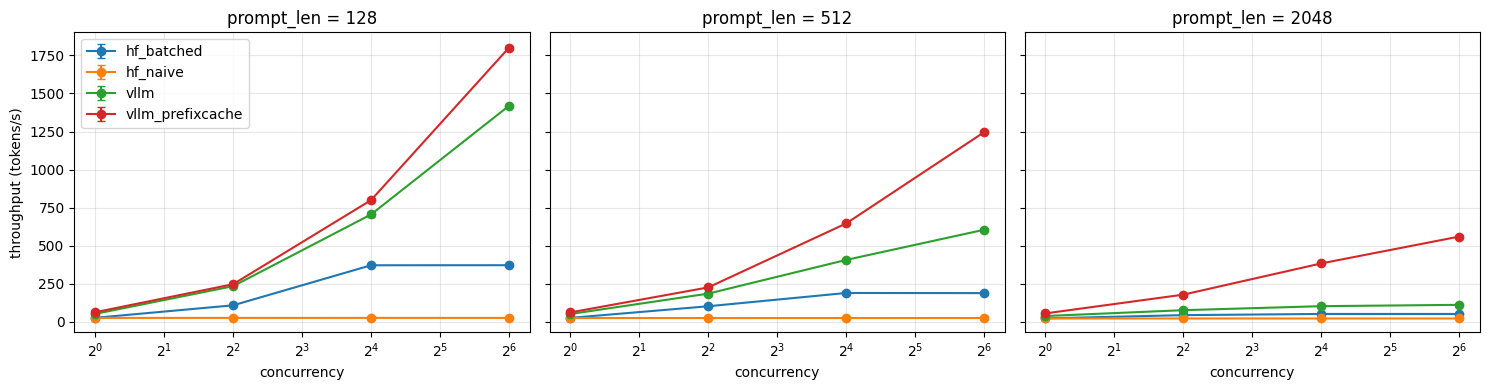

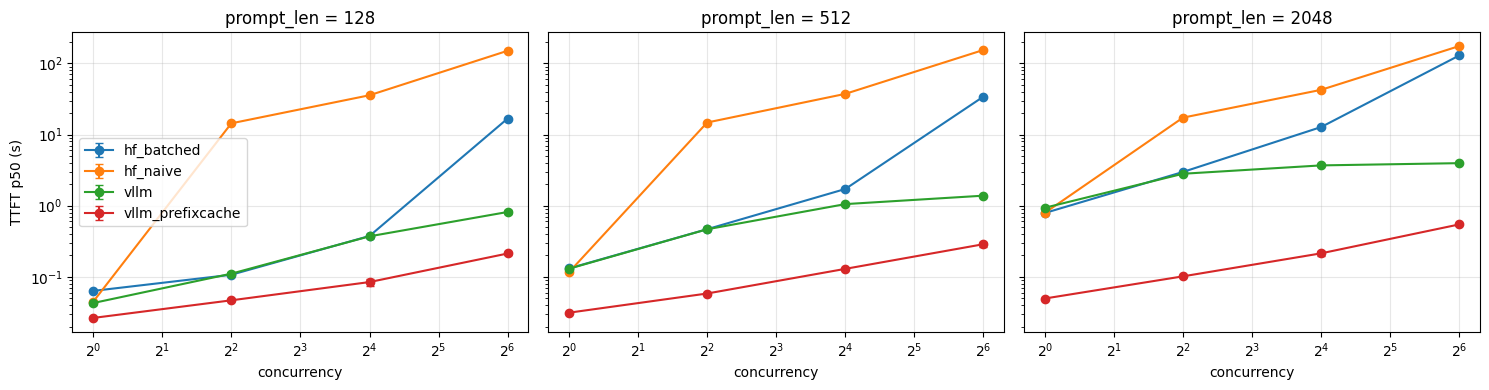

["ault args: {'model_tag': 'Qwen/Qwen2.5-1.5B-Instruct', 'model': 'Qwen/Qwen2.5-1.5B-Instruct', 'dtype': 'float16', 'max_model_len': 4096, 'gpu_memory_utilization': 0.85, 'enable_prefix_caching': False}", "e']), enable_flashinfer_autotune=True, enable_cutedsl_warmup=True, enable_jit_warmup=True, moe_backend='auto', sparse_indexer_topk_backend='auto', linear_backend='auto', linear_backend_per_quant=None)", '(EngineCore pid=691) INFO 10-01 22:41:19 [utils.py:320] Using LBNHC KV cache layout.', '(EngineCore pid=691) INFO 10-01 22:41:34 [gpu_worker.py:640] Available KV cache memory: 8.67 GiB', '65 without CUDA graph memory profiling. To maintain the same effective KV cache size as before, increase --gpu-memory-utilization to 0.8735. To disable, set VLLM_MEMORY_PROFILER_ESTIMATE_CUDAGRAPHS=0.', '(EngineCore pid=691) INFO 10-01 22:41:34 [kv_cache_utils.py:2395] GPU KV cache size: 324,704 tokens, Maximum concurrency for 4,096 tokens per request: 79.27x']
Zipped to /kaggle/working/llm-lab-resu

In [9]:
import re
import pandas as pd
import matplotlib.pyplot as plt


def plot_metric(agg, mean_col, std_col, ylabel, fname, logy=False):
    lens = sorted(agg.prompt_len.unique())
    fig, axes = plt.subplots(1, len(lens), figsize=(5 * len(lens), 4), sharey=True)
    axes = [axes] if len(lens) == 1 else axes
    for ax, plen in zip(axes, lens):
        for backend, g in agg[agg.prompt_len == plen].groupby("backend"):
            ax.errorbar(g.concurrency, g[mean_col], yerr=g[std_col], marker="o",
                        capsize=3, label=backend)
        ax.set_xscale("log", base=2)
        if logy:
            ax.set_yscale("log")
        ax.set_title(f"prompt_len = {plen}")
        ax.set_xlabel("concurrency")
        ax.grid(alpha=0.3)
    axes[0].set_ylabel(ylabel)
    axes[0].legend()
    fig.tight_layout()
    fig.savefig(ROOT / "plots" / fname, dpi=150)
    plt.show()


def analyze(df):
    # Raw table with every single run, useful for checking variance later
    df.to_csv(ROOT / "results/all_runs.csv", index=False)

    agg = df.groupby(["backend", "prompt_len", "concurrency"]).agg(
        thr_mean=("throughput_tok_s", "mean"), thr_std=("throughput_tok_s", "std"),
        ttft_p50=("ttft_p50_s", "mean"), ttft_std=("ttft_p50_s", "std"),
        ttft_p95=("ttft_p95_s", "mean"), peak_mib=("peak_gpu_mib", "max"),
    ).reset_index().fillna(0)
    agg.to_csv(ROOT / "results/summary.csv", index=False)
    pd.set_option("display.max_rows", 200)
    display(agg.round(3))

    plot_metric(agg, "thr_mean", "thr_std", "throughput (tokens/s)",
                "throughput_vs_concurrency.png")
    plot_metric(agg, "ttft_p50", "ttft_std", "TTFT p50 (s)",
                "ttft_vs_concurrency.png", logy=True)


rows = []
for f in sorted((ROOT / "results").glob("*_p*_r*.json")):
    m = re.match(r"(.+)_p(\d+)_r(\d+)\.json", f.name)
    d = json.loads(f.read_text())
    for r in d["rows"]:
        rows.append({**r, "backend": m[1], "prompt_len": int(m[2]), "rep": int(m[3])})
df = pd.DataFrame(rows)

if df.empty:
    print("No result files found, check logs/ for server errors")
else:
    print(df.groupby("backend").size())
    analyze(df)

# KV cache info from the new vLLM run
vllm_log = ROOT / "logs/vllm_server.log"
if vllm_log.exists():
    print([l[-200:] for l in vllm_log.read_text().splitlines()
           if "KV cache" in l or "prefix" in l.lower()][:6])

# Always zip, even if something failed, so the logs are never lost
shutil.make_archive("/kaggle/working/llm-lab-results", "zip", ROOT)
print("Zipped to /kaggle/working/llm-lab-results.zip")